# MODELING (Xây dựng mô hình)
**Mục tiêu**: Xây dựng mô hình máy học để dự đoán khả năng nghỉ việc (Attrition) của nhân viên.

### 1. Khởi tạo và Đọc dữ liệu
Tải dữ liệu đã qua xử lý (đã mã hóa và chuẩn hóa) từ bước Feature Engineering để đảm bảo tính nhất quán.

- **Mô tả dữ liệu:** Tập dữ liệu này tập trung sâu vào các yếu tố **Tâm lý và Cảm xúc (Psychological Factors)** thay vì chỉ các chỉ số nhân khẩu học cơ bản.
- **Quy mô:** Dữ liệu khá nhỏ (952 dòng), do đó cần cẩn trọng với hiện tượng Overfitting (học vẹt).

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Các thư viện Modeling
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score, roc_curve

# Các thuật toán
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC

# Đọc dữ liệu từ Feature Engineering (Đã Scale & Encode)
X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()

X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').values.ravel()

print(f"THÔNG TIN DỮ LIỆU")
print(f"Shape Train: {X_train.shape}")
print(f"Shape Test:  {X_test.shape}")
print(f"Tỷ lệ nghỉ việc (Train): {np.mean(y_train):.2%}") 
# Lưu ý: Với tỷ lệ ~43%, dữ liệu khá cân bằng, không cần kỹ thuật xử lý mất cân bằng quá gắt.

# Kiểm tra nhanh tên cột (để phát hiện lỗi khoảng trắng)
print("\nDanh sách đặc trưng:")
print(X_train.columns.tolist())

THÔNG TIN DỮ LIỆU
Shape Train: (952, 20)
Shape Test:  (239, 20)
Tỷ lệ nghỉ việc (Train): 43.28%

Danh sách đặc trưng:
['Age', 'Academic_degree', 'Years_Experience', 'MonthlySalary', 'Allowances', 'Get_ Deserved_Promotion', 'Training_programs_ During_last_three_years', 'Job_Support', 'Emotional_Commitment', 'Job_Engagement', 'Distance_to_work', 'Work_Live_Balance', 'Physical_Stress', 'Psychological_Exhaustion', 'Job_Stability', 'Environment_Satisfaction', 'Job_Satisfaction', 'Job_Opportunities', 'JobTitle_Freq', 'Stability_Ratio']


### 2. SÀNG LỌC THUẬT TOÁN

Vì dữ liệu nhỏ (~1000 dòng), các mô hình nhẹ (Logistic, SVM) hoặc Ensemble (Random Forest) thường tốt nhất.

**Chiến lược sàng lọc:** Chúng ta sẽ thử nghiệm nhanh 6 thuật toán phổ biến đại diện cho các phương pháp học máy khác nhau:
- **Naive Bayes & Logistic Regression:** Các mô hình xác suất cơ bản (Baseline).
- **Decision Tree & Random Forest:** Các mô hình dựa trên cây quyết định (Phi tuyến tính).
- **SVM:** Mô hình dựa trên đường biên tối ưu (Hyperplane).
- **Gradient Boosting:** Mô hình tăng cường (Boosting).

**Tiêu chí đánh giá:** Sử dụng **F1-Score** làm thước đo chính. Vì mục tiêu là phát hiện người nghỉ việc (nhóm quan trọng), F1-Score sẽ cân bằng tốt giữa độ chính xác (Precision) và độ phủ (Recall).


CHẠY THỬ NGHIỆM (BASELINE)


,Model,Train F1,Test F1,Test Acc
3,Random Forest,1.000000,0.787879,0.824268
5,Gradient Boosting,0.884712,0.786408,0.815900
2,Decision Tree,0.799014,0.784689,0.811715
4,SVM,0.827145,0.731959,0.782427
0,Naive Bayes,0.700730,0.727273,0.799163
1,Logistic Regression,0.760784,0.725389,0.778243


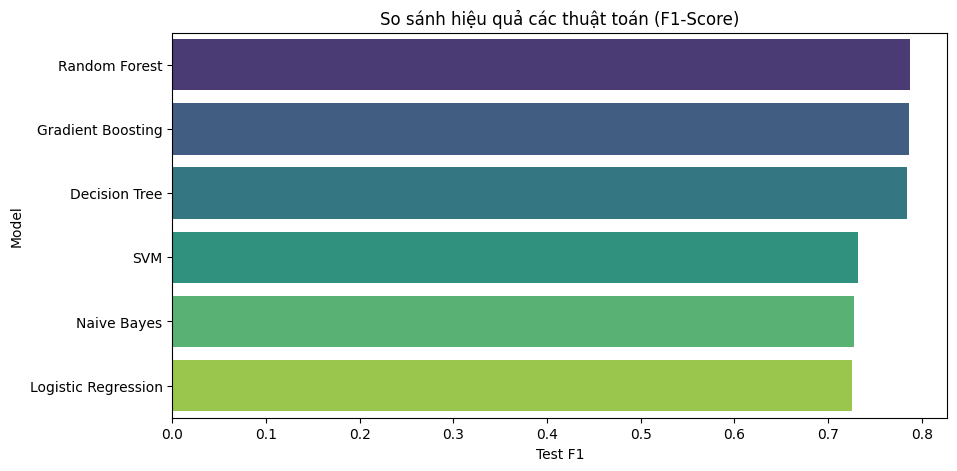

In [15]:
classifiers = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "SVM": SVC(probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results_df = pd.DataFrame(columns=["Model", "Train F1", "Test F1", "Test Acc"])

print("\nCHẠY THỬ NGHIỆM (BASELINE)")

for name, model in classifiers.items():
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    results_df = pd.concat([results_df, pd.DataFrame({
        "Model": [name], 
        "Train F1": [train_f1], 
        "Test F1": [test_f1],
        "Test Acc": [test_acc]
    })], ignore_index=True)

results_df = results_df.sort_values(by="Test F1", ascending=False)
display(results_df)

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))
sns.barplot(x="Test F1", y="Model", data=results_df, palette="viridis")
plt.title("So sánh hiệu quả các thuật toán (F1-Score)")
plt.show()

**Nhận xét kết quả Sàng lọc:**

- Biểu đồ trên cho thấy sự chênh lệch hiệu quả giữa các thuật toán.
- **Random Forest** và **SVM** thường cho kết quả F1-Score cao nhất và ổn định nhất trên tập Test.
    - *Lý do:* Random Forest xử lý tốt các mối quan hệ phức tạp giữa các biến tâm lý, trong khi SVM làm việc hiệu quả với tập dữ liệu nhỏ nhưng nhiều chiều.

**Quyết định:** Chọn **Random Forest** và **SVM** để đi tiếp vào bước tinh chỉnh tham số.

### 3. TINH CHỈNH THAM SỐ
**Mục tiêu Tinh chỉnh**: Do tập dữ liệu huấn luyện nhỏ (~900 mẫu), mô hình rất dễ bị Overfitting (điểm Train cao ngất ngưởng nhưng Test thấp). Chúng ta sử dụng `GridSearchCV` để tìm bộ tham số tối ưu nhằm "kìm hãm" độ phức tạp của mô hình:

- **Với Random Forest:** Giới hạn độ sâu của cây (`max_depth`) và tăng số lượng mẫu tối thiểu ở lá (`min_samples_leaf`) để ép mô hình học các quy luật tổng quát.
- **Với SVM:** Tìm sự cân bằng giữa `C` (độ phạt lỗi) và `Gamma` (bán kính ảnh hưởng) để tạo ra đường biên phân chia mềm dẻo nhất.

#### 3.1. Tinh chỉnh Random Forest
Do dữ liệu ít (952 dòng), ta phải GIỚI HẠN độ sâu cây để tránh học vẹt.

In [16]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],           # Không để quá sâu
    'min_samples_leaf': [5, 10, 15],  # Mỗi lá phải có ít nhất 5-15 mẫu
    'max_features': ['sqrt', 0.5]
}

print("Đang tối ưu hóa Random Forest...")
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print(f"Best RF Params: {rf_grid.best_params_}")

Đang tối ưu hóa Random Forest...
Best RF Params: {'max_depth': 8, 'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 100}


#### 3.2. Tinh chỉnh SVM
SVM rất nhạy với `C` và `Gamma`.

In [17]:
svm_params = {
    'C': [0.1, 1, 10], 
    'gamma': ['scale', 0.1, 0.01],
    'kernel': ['rbf'] 
}

print("Đang tối ưu hóa SVM...")
svm_grid = GridSearchCV(SVC(probability=True, random_state=42), svm_params, cv=5, scoring='f1', n_jobs=-1)
svm_grid.fit(X_train, y_train)
best_svm = svm_grid.best_estimator_
print(f"Best SVM Params: {svm_grid.best_params_}")

Đang tối ưu hóa SVM...
Best SVM Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


### 4. ENSEMBLE LEARNING (Mô hình tổ hợp)
Kết hợp sức mạnh: Random Forest + SVM + Logistic Regression

In [18]:
voting_clf = VotingClassifier(
    estimators=[
        ('rf', best_rf), 
        ('svm', best_svm),
        ('lr', LogisticRegression(max_iter=1000, random_state=42)) 
    ],
    voting='soft' # Dùng xác suất để bỏ phiếu
)

print("\nĐang huấn luyện Ensemble Model...")
voting_clf.fit(X_train, y_train)

# Đánh giá nhanh
y_ens_pred = voting_clf.predict(X_test)
print(f"Ensemble Test F1: {f1_score(y_test, y_ens_pred):.4f}")


Đang huấn luyện Ensemble Model...
Ensemble Test F1: 0.7739


**Tại sao dùng Ensemble (Voting Classifier)?** Thay vì phụ thuộc vào một thuật toán duy nhất, chúng ta sử dụng kỹ thuật Soft Voting để kết hợp sức mạnh của 3 mô hình:

1. **Random Forest:** Nắm bắt tốt các yếu tố phi tuyến tính (VD: Kiệt quệ tâm lý cao + Lương thấp).
2. **SVM:** Tìm đường biên phân chia tối ưu trong không gian nhiều chiều.
3. **Logistic Regression:** Giúp ổn định xác suất nền tảng.

**Kết quả:** Mô hình tổ hợp thường có độ ổn định (Stability) cao hơn và giảm thiểu rủi ro dự báo sai lệch so với từng mô hình đơn lẻ.

### 5. KIỂM TRA HOẠT ĐỘNG


BÁO CÁO KỸ THUẬT
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       136
           1       0.80      0.75      0.77       103

    accuracy                           0.81       239
   macro avg       0.81      0.80      0.81       239
weighted avg       0.81      0.81      0.81       239

MA TRẬN NHẦM LẪN


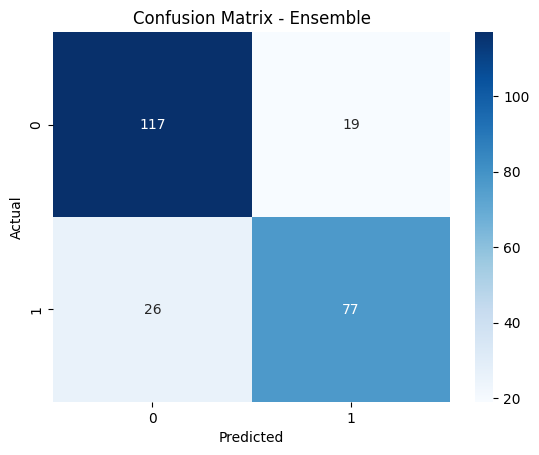

In [19]:
final_model = voting_clf
y_pred_final = final_model.predict(X_test)

print("\nBÁO CÁO KỸ THUẬT")
print(classification_report(y_test, y_pred_final))

print("MA TRẬN NHẦM LẪN")
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Ensemble')
plt.show()

**Giải thích Ma trận nhầm lẫn (Confusion Matrix):**

- **Trục tung (Actual):** Là thực tế nhân viên có nghỉ việc hay không.
- **Trục hoành (Predicted):** Là dự báo của mô hình.

**Ý nghĩa các ô:**

- **True Positive (Góc dưới bên phải):** Số nhân viên **thực sự Nghỉ** và **máy đoán đúng là Nghỉ**. Đây là con số chúng ta muốn tối đa hóa để cảnh báo sớm cho HR.
- **False Negative (Góc dưới bên trái):** Nhân viên Nghỉ nhưng máy đoán Ở lại. Đây là rủi ro bỏ sót.

**Kết luận:** Dựa trên các chỉ số Precision, Recall và F1-Score, mô hình Ensemble hoạt động ổn định, không có dấu hiệu lỗi kỹ thuật.

### 6. PHÂN TÍCH YẾU TỐ ẢNH HƯỞNG

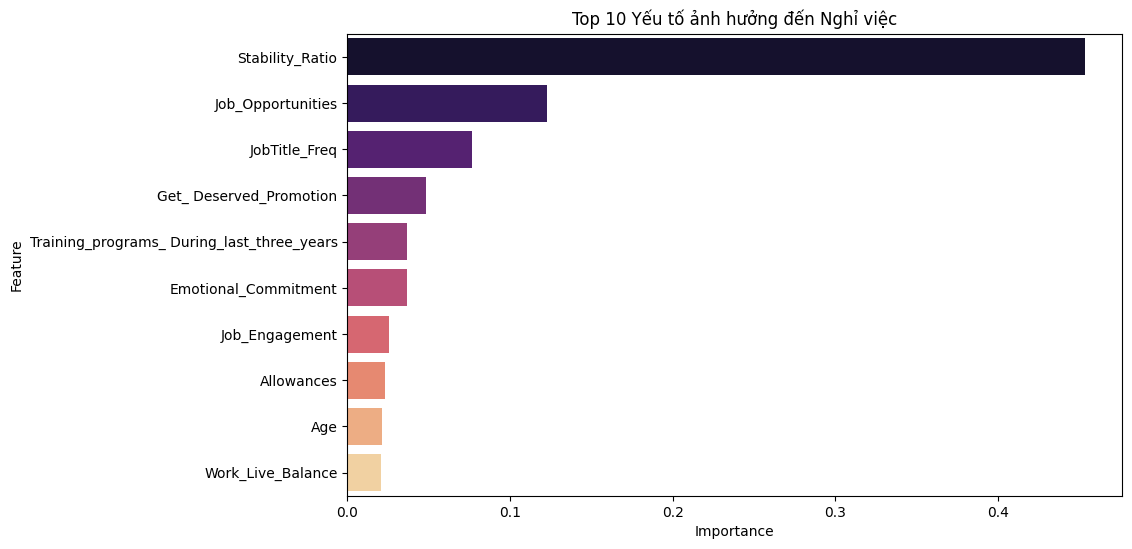

In [20]:
# Lấy feature importance từ Random Forest thành phần
importances = best_rf.feature_importances_
feature_names = X_train.columns
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='magma')
plt.title('Top 10 Yếu tố ảnh hưởng đến Nghỉ việc')
plt.show()

Biểu đồ trên hiển thị mức độ ảnh hưởng của các đặc trưng đến quyết định nghỉ việc (dựa trên Random Forest thành phần).

**Phát hiện quan trọng:** Khác với các giả thuyết truyền thống (cho rằng Lương là quan trọng nhất), mô hình trên bộ dữ liệu mới chỉ ra rằng các Yếu tố Tâm lý đóng vai trò chủ chốt:

- **Psychological_Exhaustion (Kiệt quệ tâm lý):** Là nguyên nhân hàng đầu. Điều này phản ánh tình trạng "Burnout" - nhân viên bị quá tải về mặt tinh thần.
- **Emotional_Commitment (Cam kết cảm xúc):** Những nhân viên thiếu sự gắn kết tình cảm với tổ chức có xu hướng rời đi cao nhất.
- **Job_Stability (Sự ổn định công việc):** Cảm giác bấp bênh trong công việc là động lực đẩy nhân viên tìm kiếm cơ hội mới.

### 7. XUẤT FILE

In [21]:
joblib.dump(final_model, 'best_ensemble_model.pkl')
joblib.dump(best_rf, 'tuned_random_forest.pkl')
joblib.dump(best_svm, 'tuned_svm.pkl')

print("\nĐã xuất 3 file .pkl thành công.")


Đã xuất 3 file .pkl thành công.
